In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [23]:
# Load the data
df = pd.read_csv(r'C:\Users\suraj\Downloads\archive (1)\superstore.csv', encoding='latin1')

# See the first 5 rows
df.head(5)


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,è®°å½æ°,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [35]:
# Get the name of the column at index 7
column_to_drop = df.columns[7]

# Drop it using the retrieved name
df = df.drop(columns=[column_to_drop])

print("Column dropped successfully by position.")

Column dropped successfully by position.


In [36]:
# Drop the problematic column

# Clean the rest of the column names (replace '.' with '_')
df.columns = df.columns.str.replace('.', '_', regex=False)

# See the new, cleaned column names
print("Cleaned Column Names:")
print(df.columns)

Cleaned Column Names:
Index(['Category', 'City', 'Country', 'Customer_ID', 'Customer_Name',
       'Discount', 'Market', 'Order_Date', 'Order_ID', 'Order_Priority',
       'Product_ID', 'Product_Name', 'Profit', 'Quantity', 'Region', 'Row_ID',
       'Sales', 'Segment', 'Ship_Date', 'Ship_Mode', 'Shipping_Cost', 'State',
       'Sub_Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')


In [22]:
# Get a summary of columns, data types, and null values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   è®°å½æ°       51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [37]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Check for missing values (and handle if necessary)
print("\nMissing Values:")
print(df.isnull().sum())

# Convert date columns to datetime objects
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])

# Handle outliers in Sales and Profit
for col in ['Sales', 'Profit']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"\nShape of the dataframe after cleaning: {df.shape}")


Missing Values:
Category          0
City              0
Country           0
Customer_ID       0
Customer_Name     0
Discount          0
Market            0
Order_Date        0
Order_ID          0
Order_Priority    0
Product_ID        0
Product_Name      0
Profit            0
Quantity          0
Region            0
Row_ID            0
Sales             0
Segment           0
Ship_Date         0
Ship_Mode         0
Shipping_Cost     0
State             0
Sub_Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

Shape of the dataframe after cleaning: (34011, 26)


              Sales        Profit      Discount      Quantity  Shipping_Cost
count  34011.000000  34011.000000  34011.000000  34011.000000   34011.000000
mean      67.267384      9.000263      0.128761      3.004381       7.310650
std       63.907404     15.773357      0.202977      1.961781       9.396177
min        0.000000    -31.806000      0.000000      1.000000       0.002000
25%       21.000000      0.800000      0.000000      2.000000       1.690000
50%       46.000000      6.540000      0.000000      2.000000       4.070000
75%       94.000000     17.280000      0.200000      4.000000       9.163500
max      310.000000     52.260000      0.800000     14.000000     130.570000


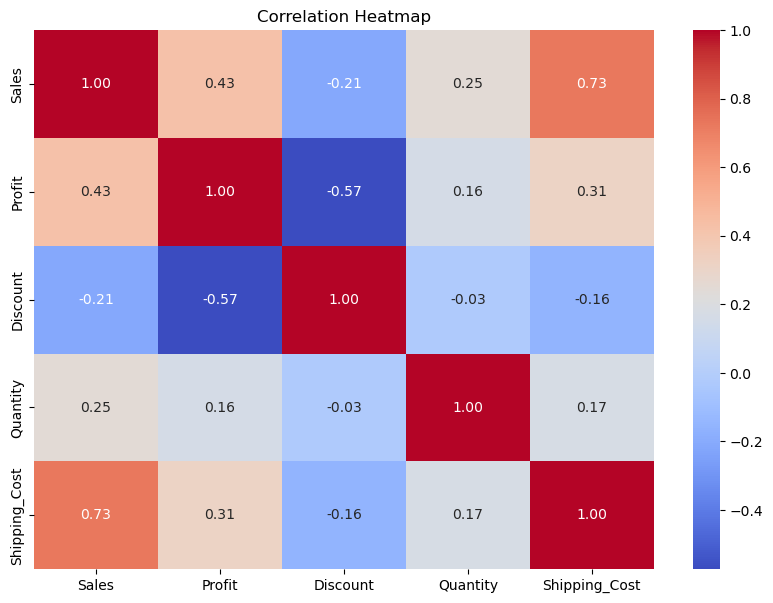

In [38]:
# Get descriptive statistics for key numerical columns
print(df[['Sales', 'Profit', 'Discount', 'Quantity', 'Shipping_Cost']].describe())

# Create a correlation heatmap
plt.figure(figsize=(10, 7))
correlation_matrix = df[['Sales', 'Profit', 'Discount', 'Quantity', 'Shipping_Cost']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

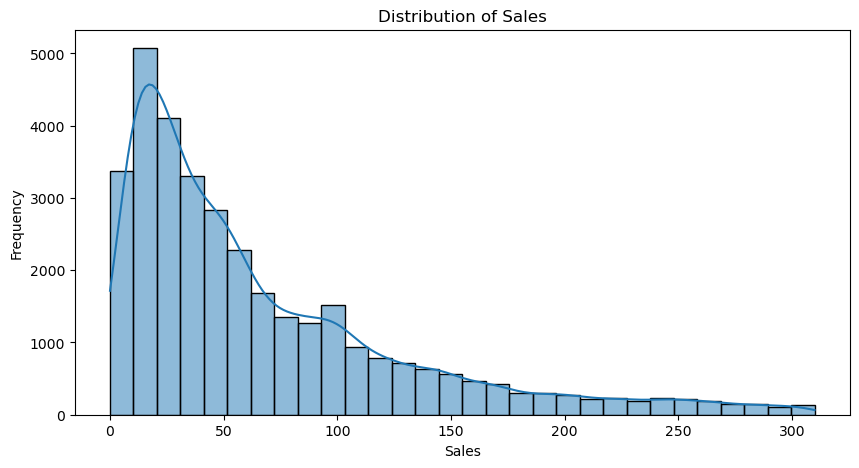

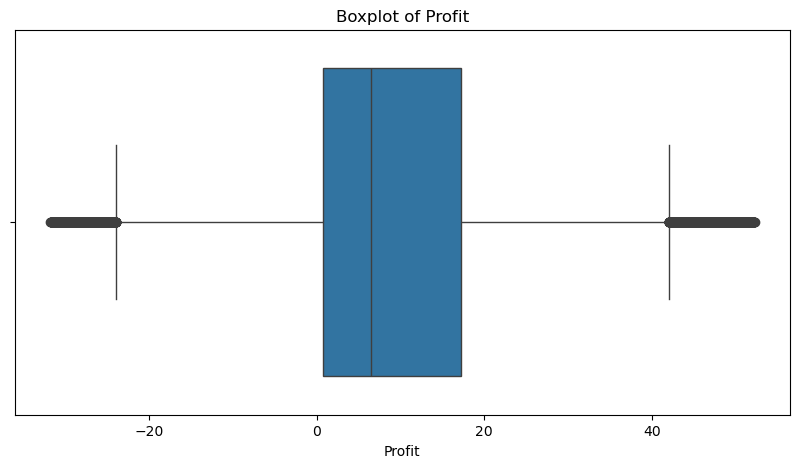

In [39]:
# Histogram for Sales distribution to see how frequently different sales amounts occur
plt.figure(figsize=(10, 5))
sns.histplot(df['Sales'], kde=True, bins=30)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

# Boxplot to identify the spread and potential outliers in Profit
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Profit'])
plt.title('Boxplot of Profit')
plt.xlabel('Profit')
plt.show()

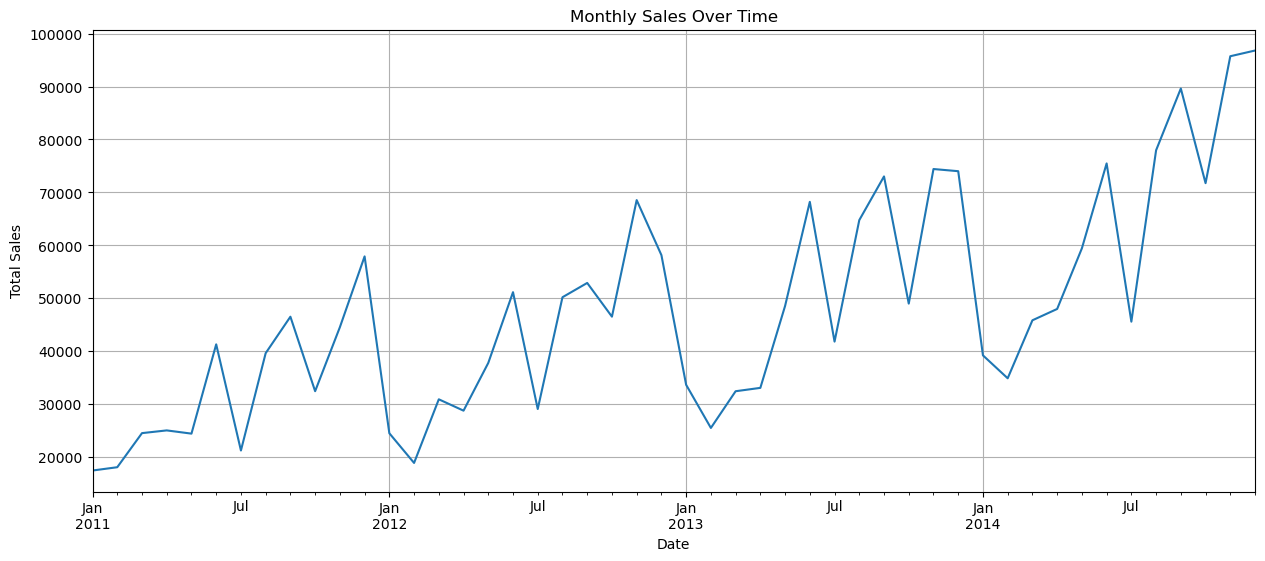

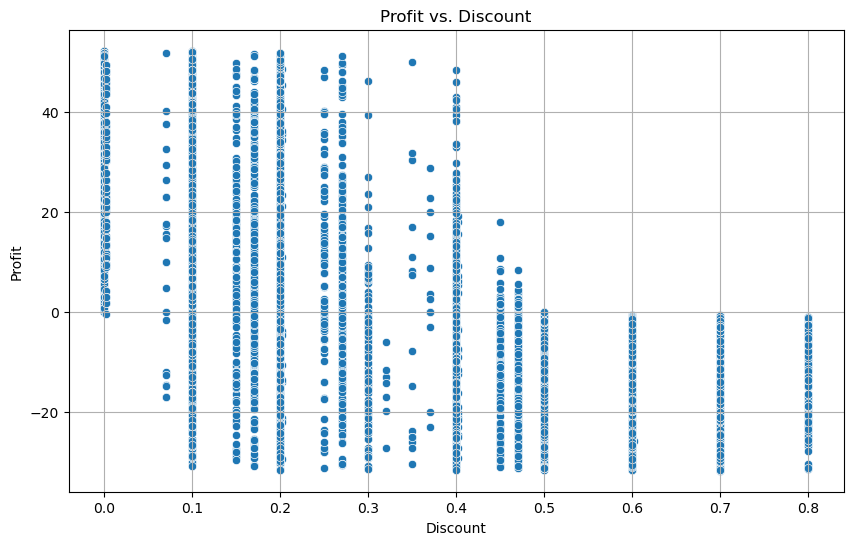

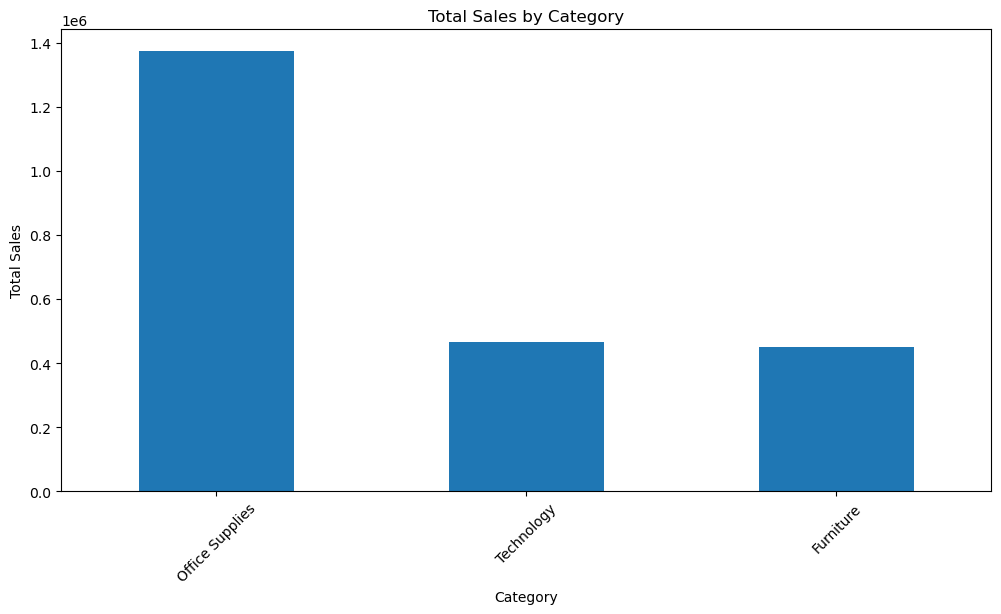

In [42]:
# Time series plot for sales trends over the years
# We need to set 'Order_Date' as the index to resample the data by month
df.set_index('Order_Date')['Sales'].resample('ME').sum().plot(figsize=(15, 6))
plt.title('Monthly Sales Over Time')
plt.ylabel('Total Sales')
plt.xlabel('Date')
plt.grid(True)
plt.show()
# IMPORTANT: Reset the index so 'Order_Date' becomes a regular column again for the next steps
df.reset_index(inplace=True)

# Scatter plot to see the relationship between Profit and Discount
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit')
plt.title('Profit vs. Discount')
plt.grid(True)
plt.show()

# Bar plot to compare total sales across different product Categories
plt.figure(figsize=(12, 6))
df.groupby('Category')['Sales'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Sales by Category')
plt.ylabel('Total Sales')
plt.xlabel('Category')
plt.xticks(rotation=45) # Rotate category names for better readability
plt.show()

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 1. Define your features (X) and target (y)
X = df[['Profit', 'Discount']]
y = df['Sales']

# 2. Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Use the trained model to make predictions on the test data
y_pred = model.predict(X_test)

# 5. Evaluate the model's performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"\n--- Model Performance ---")
print(f"R-squared (R²) score: {r2:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"This means the model can explain about {r2:.0%} of the variance in sales based on profit and discount.")


--- Model Performance ---
R-squared (R²) score: 0.16
Mean Squared Error (MSE): 3388.16
This means the model can explain about 16% of the variance in sales based on profit and discount.
